# Verifying the packed `[[448,64,7]]` Ising/STAR code with qLDPC

This notebook reconstructs the recommended self-dual polynomial GALA/BB code and checks the static conditions needed by the packed bipartite Ising architecture. The physical group is `C_56 x C_4`, with thickness subgroup `<x^8> = C_7`, and the logical translation quotient is `C_8 x C_4`.

The candidate is

$$a=(1+x^8)+x(1+x^{24})+x^8y(1+x^{16})=1+x+x^8+x^8y+x^{24}y+x^{25},$$

with `b = a^dagger`. The notebook distinguishes proved static code properties from circuit-level STAR properties that still require simulation.

## 1. Environment and construction

Run this notebook from the root of `gala-code-search` with its `.venv` environment. The code itself is constructed by qLDPC's `GroupRing`, `AbelianGroup`, and `GALACode` implementations; the local `gala_search.packed` module supplies the searched candidate and reproducible acceptance tests.

In [1]:
from pathlib import Path
import importlib.metadata
import json
import os

PROJECT = Path.cwd().resolve()
assert (PROJECT / 'gala_search' / 'packed.py').exists(), 'Run from gala-code-search'
os.environ.setdefault('NUMBA_CACHE_DIR', str(PROJECT / 'results' / 'numba-cache'))
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT / 'results' / 'matplotlib-cache'))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from qldpc import codes

from gala_search.packed import (
    LOGICALS_PER_HALF,
    NUM_LOGICALS,
    PackedWeightTwelveCandidate,
    _group_action_permutations,
    analyze_packed_candidate,
    certify_packed_distance,
    packed_automorphism_checks,
    packed_logicals,
    polynomial_member,
)

print('qLDPC version:', importlib.metadata.version('qldpc'))
print('Project:', PROJECT)

qLDPC version: 0.3.3
Project: /home/judah_unmuth/gala-code-search


In [2]:
candidate = PackedWeightTwelveCandidate(
    m=7, r0=1, r1=3, r2=2, p1=0, p2=1
)
a = polynomial_member(candidate)

# This is the minimal two-block polynomial GALA construction. Because the
# lift group is C_56 x C_4, it is also a bivariate-bicycle code.
code = codes.GALACode(
    generators_f=[a],
    generators_g=[a.T],
    num_active_rows=1,
)

print('Candidate:', candidate.candidate_id)
print('a(x,y) =', candidate.polynomial)
print('qLDPC class:', type(code).__name__)
print('H_X shape:', code.matrix_x.shape)

Candidate: packed12-m7-r1-3-2-p0-1
a(x,y) = 1 + x^1 + x^8 + x^8 y^1 + x^24 y^1 + x^25
qLDPC class: GALACode
H_X shape: (224, 448)


## 2. Code parameters, LDPC checks, and connectedness

For a self-dual CSS code with one common check matrix `H`, `k = n - 2 rank(H)`. The required result is `rank(H)=192`, hence `k=448-384=64`. Each check has weight 12 and every physical qubit participates in six checks of each CSS type.

In [3]:
analysis = analyze_packed_candidate(candidate)
H_X = np.asarray(code.matrix_x, dtype=np.uint8)
H_Z = np.asarray(code.matrix_z, dtype=np.uint8)
row_weights = np.count_nonzero(H_X, axis=1)
column_weights = np.count_nonzero(H_X, axis=0)

parameter_summary = {
    'n': code.num_qubits,
    'k': code.dimension,
    'rank(H)': code.code_x.rank,
    'check weight': sorted(set(row_weights.tolist())),
    'qubit degree / CSS type': sorted(set(column_weights.tolist())),
    'Tanner connected': analysis['checks']['tanner_connected'],
}
display(parameter_summary)

assert parameter_summary == {
    'n': 448,
    'k': 64,
    'rank(H)': 192,
    'check weight': [12],
    'qubit degree / CSS type': [6],
    'Tanner connected': True,
}

{'n': 448,
 'k': 64,
 'rank(H)': 192,
 'check weight': [12],
 'qubit degree / CSS type': [6],
 'Tanner connected': True}

## 3. ZX duality and exact transversal Clifford actions

The choice `b=a^dagger` makes `H_X=H_Z=[A | A^T]`. Therefore physical `H` swaps the two stabilizer groups. The logical X and Z operators below use identical supports, so physical `H` swaps each logical X with its own logical Z without a logical permutation.

The weight-12 X checks are doubly even. Thus physical `S` preserves the stabilizer group. Since each canonical logical support has weight 7 modulo 4, its induced action is uniform logical `S^dagger` (up to the conventional Pauli phase), rather than logical `S`.

In [4]:
logicals = packed_logicals(candidate).astype(np.uint8)
logical_pairing = (logicals @ logicals.T) % 2

zx_clifford_checks = {
    'H_X equals H_Z': np.array_equal(H_X, H_Z),
    'CSS orthogonality H_X H_Z^T = 0': not np.any((H_X @ H_Z.T) % 2),
    'same-support logical X/Z pairing is I_64': np.array_equal(
        logical_pairing, np.eye(NUM_LOGICALS, dtype=np.uint8)
    ),
    'all X-check weights are 0 mod 4': np.all(row_weights % 4 == 0),
    'logical support weight is 3 mod 4 (logical S^dagger)': np.all(
        np.count_nonzero(logicals, axis=1) % 4 == 3
    ),
}
display(zx_clifford_checks)
assert all(zx_clifford_checks.values())

{'H_X equals H_Z': True,
 'CSS orthogonality H_X H_Z^T = 0': True,
 'same-support logical X/Z pairing is I_64': True,
 'all X-check weights are 0 mod 4': np.True_,
 'logical support weight is 3 mod 4 (logical S^dagger)': np.True_}

## 4. Exactly two disjoint `8 x 4` logical sectors

On each BB half, define

$$z_{a,b}=x^a y^b(1+x^8+x^{16}+···+x^{48}), \qquad (a,b)\in C_8\times C_4.$$

There are 32 such fibers on `L` and 32 on `R`. Every fiber has weight 7. They commute with the checks, are independent modulo the stabilizers, and form a complete orthonormal logical basis. The 64 supports are pairwise disjoint and partition all 448 physical qubits.

In [5]:
def gf2_rank(matrix):
    return int(np.linalg.matrix_rank(np.asarray(matrix, dtype=int).view(code.field)))

support_multiplicity = np.count_nonzero(logicals, axis=0)
logical_weights = np.count_nonzero(logicals, axis=1)
rank_gain = gf2_rank(np.vstack([H_X, logicals])) - gf2_rank(H_X)

logical_module_checks = {
    '64 candidate fibers': logicals.shape == (64, 448),
    '32 fibers in L and 32 in R': LOGICALS_PER_HALF == 32,
    'all fibers commute with H': not np.any((H_X @ logicals.T) % 2),
    'all fibers have weight 7': np.all(logical_weights == 7),
    'fibers are independent': gf2_rank(logicals) == 64,
    'fibers add all 64 logical dimensions': rank_gain == 64,
    'fibers are orthonormal mod 2': np.array_equal(
        logical_pairing, np.eye(64, dtype=np.uint8)
    ),
    'every physical qubit belongs to exactly one fiber': np.all(
        support_multiplicity == 1
    ),
}
display(logical_module_checks)
assert all(logical_module_checks.values())

{'64 candidate fibers': True,
 '32 fibers in L and 32 in R': True,
 'all fibers commute with H': True,
 'all fibers have weight 7': np.True_,
 'fibers are independent': True,
 'fibers add all 64 logical dimensions': True,
 'fibers are orthonormal mod 2': True,
 'every physical qubit belongs to exactly one fiber': np.True_}

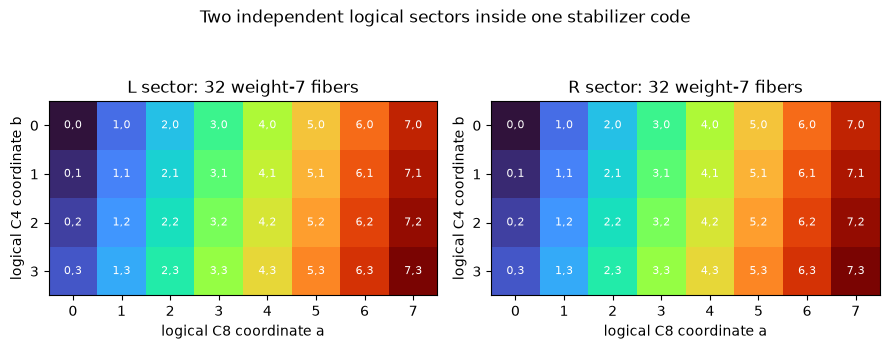

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for half, (axis, name) in enumerate(zip(axes, ['L sector', 'R sector'])):
    ownership = np.arange(32).reshape(8, 4)
    axis.imshow(ownership.T, cmap='turbo', aspect='equal')
    for a_index in range(8):
        for b_index in range(4):
            axis.text(a_index, b_index, f'{a_index},{b_index}',
                      ha='center', va='center', color='white', fontsize=8)
    axis.set_title(f'{name}: 32 weight-7 fibers')
    axis.set_xlabel('logical C8 coordinate a')
    axis.set_ylabel('logical C4 coordinate b')
    axis.set_xticks(range(8))
    axis.set_yticks(range(4))
fig.suptitle('Two independent logical sectors inside one stabilizer code')
fig.tight_layout()
plt.show()

## 5. Logical translations and the important lockstep limitation

Physical translations by `x` and `y` preserve the stabilizer group and induce regular `C_8` and `C_4` actions on each logical sector. They act diagonally:

$$T_x=T_x^{(L)}\otimes T_x^{(R)}, \qquad T_y=T_y^{(L)}\otimes T_y^{(R)}.$$

They do **not** provide `T_x^(L) tensor I_R` or `I_L tensor T_x^(R)`. The following calculation checks stabilizer row-space preservation, which is stronger evidence than merely comparing displayed check generators.

In [7]:
automorphisms = packed_automorphism_checks(candidate)
display(automorphisms)
assert all(automorphisms.values())

group_order = candidate.group_order
perm_x, perm_y, inversion = _group_action_permutations(candidate.m)
identity = np.arange(group_order)

def permuted_check(permutation):
    transformed = np.zeros_like(H_X)
    transformed[:, permutation] = H_X
    return transformed

def preserves_stabilizer_row_space(permutation):
    transformed = permuted_check(permutation)
    return gf2_rank(np.vstack([H_X, transformed])) == gf2_rank(H_X)

translation_scope = {
    'x on L and R together': preserves_stabilizer_row_space(
        np.hstack([perm_x, group_order + perm_x])
    ),
    'x on L only': preserves_stabilizer_row_space(
        np.hstack([perm_x, group_order + identity])
    ),
    'x on R only': preserves_stabilizer_row_space(
        np.hstack([identity, group_order + perm_x])
    ),
    'y on L and R together': preserves_stabilizer_row_space(
        np.hstack([perm_y, group_order + perm_y])
    ),
    'y on L only': preserves_stabilizer_row_space(
        np.hstack([perm_y, group_order + identity])
    ),
    'y on R only': preserves_stabilizer_row_space(
        np.hstack([identity, group_order + perm_y])
    ),
}
display(translation_scope)
assert translation_scope == {
    'x on L and R together': True,
    'x on L only': False,
    'x on R only': False,
    'y on L and R together': True,
    'y on L only': False,
    'y on R only': False,
}

{'x_translation_stabilizer_automorphism': True,
 'y_translation_stabilizer_automorphism': True,
 'half_swap_inversion_automorphism': True}

{'x on L and R together': True,
 'x on L only': False,
 'x on R only': False,
 'y on L and R together': True,
 'y on L only': False,
 'y on R only': False}

In [8]:
regular_action_checks = {
    'x induces C8 on both sectors': analysis['checks']['x_translation_is_C8'],
    'y induces C4 on both sectors': analysis['checks']['y_translation_is_C4'],
}
display(regular_action_checks)
assert all(regular_action_checks.values())

{'x induces C8 on both sectors': True, 'y induces C4 on both sectors': True}

## 6. All four nearest-neighbor Ising bond matchings

Parameterize the even checkerboard sublattice by `E(a,b) = a(1,1) + b(0,2)` on the periodic `8 x 8` square lattice. This is a `C_8 x C_4` torsor. Identify `O(a,b)` with the east neighbor of `E(a,b)`. The code below verifies the required odd-sublattice shifts for all 32 even sites and every nearest-neighbor direction.

In [9]:
def add_square(left, right):
    return ((left[0] + right[0]) % 8, (left[1] + right[1]) % 8)

def even_site(a_index, b_index):
    return (a_index % 8, (a_index + 2 * b_index) % 8)

def odd_site(a_index, b_index):
    return add_square(even_site(a_index, b_index), (1, 0))

directions = {
    'East': (1, 0),
    'West': (-1, 0),
    'North': (0, 1),
    'South': (0, -1),
}
# Exponents of the logical/code translations X and Y.
matching_shifts = {
    'East': (0, 0),       # I
    'West': (-2, 1),      # X^-2 Y
    'North': (-1, 1),     # X^-1 Y
    'South': (-1, 0),     # X^-1
}

for a_index in range(8):
    for b_index in range(4):
        source = even_site(a_index, b_index)
        for direction, displacement in directions.items():
            shift_a, shift_b = matching_shifts[direction]
            expected_neighbor = add_square(source, displacement)
            matched_odd = odd_site(a_index + shift_a, b_index + shift_b)
            assert matched_odd == expected_neighbor

rows = [
    ('East', 'I'),
    ('West', 'X^-2 Y'),
    ('North', 'X^-1 Y'),
    ('South', 'X^-1'),
]
table = '| Bond | Shift on odd code block |\n|---|---|\n' + ''.join(
    f'| {direction} | `{shift}` |\n' for direction, shift in rows
)
display(Markdown(table + '\nVerified on all `32 x 4 = 128` directed matchings.'))

| Bond | Shift on odd code block |
|---|---|
| East | `I` |
| West | `X^-2 Y` |
| North | `X^-1 Y` |
| South | `X^-1` |

Verified on all `32 x 4 = 128` directed matchings.

## 7. Transversal CNOT between checkerboard code blocks

Use two identical `[[448,64,7]]` QEC blocks, one for the even sublattice and one for the odd sublattice. A physical bitwise CNOT between identical CSS blocks maps each canonical logical support to the corresponding support in the other block. Consequently it performs 64 logical CNOTs in parallel: 32 in the `L` replica and 32 in the `R` replica.

In [10]:
zero = np.zeros(code.num_qubits, dtype=np.uint8)

def bitwise_cnot_pauli(x_control, x_target, z_control, z_target):
    # Binary symplectic conjugation by CNOT(control -> target).
    return (
        x_control.copy(),
        x_target ^ x_control,
        z_control ^ z_target,
        z_target.copy(),
    )

for logical in logicals:
    x_c, x_t, z_c, z_t = bitwise_cnot_pauli(logical, zero, zero, zero)
    assert np.array_equal(x_c, logical) and np.array_equal(x_t, logical)
    x_c, x_t, z_c, z_t = bitwise_cnot_pauli(zero, zero, zero, logical)
    assert np.array_equal(z_c, logical) and np.array_equal(z_t, logical)

print('Verified the logical CNOT Pauli action on all 64 canonical supports.')

Verified the logical CNOT Pauli action on all 64 canonical supports.


## 8. Static support condition for parallel STAR injection

Within either simulation replica, all 32 logical-Z fibers are physically disjoint. In fact, the 64 supports across `L` and `R` partition the entire code block. This proves the static non-overlap condition needed for parallel resource injection. It does not by itself prove a fault-tolerant simultaneous-injection circuit or rule out correlated circuit faults.

In [11]:
left_logicals = logicals[:32]
right_logicals = logicals[32:]
left_overlap = left_logicals @ left_logicals.T
right_overlap = right_logicals @ right_logicals.T
cross_overlap = left_logicals @ right_logicals.T

star_support_checks = {
    'L supports have zero pairwise overlap': np.all(
        left_overlap == 7 * np.eye(32, dtype=np.uint8)
    ),
    'R supports have zero pairwise overlap': np.all(
        right_overlap == 7 * np.eye(32, dtype=np.uint8)
    ),
    'L and R supports are disjoint': not np.any(cross_overlap),
    'all supports partition 448 qubits': np.all(support_multiplicity == 1),
}
display(star_support_checks)
assert all(star_support_checks.values())

{'L supports have zero pairwise overlap': np.True_,
 'R supports have zero pairwise overlap': np.True_,
 'L and R supports are disjoint': True,
 'all supports partition 448 qubits': np.True_}

## 9. Even syndrome parity used by the one-round STAR check

Every qubit appears in six checks of either CSS type. Therefore the parity of `H e` is always even for any error vector `e`, so a nonzero syndrome can never have weight one. The random examples below illustrate the algebraic identity `1^T H = 0`; the first assertion proves it for all errors.

In [12]:
assert np.all(np.sum(H_X, axis=0) % 2 == 0)
rng = np.random.default_rng(20260824)
sample_syndrome_weights = []
for _ in range(20):
    error = rng.integers(0, 2, size=code.num_qubits, dtype=np.uint8)
    syndrome = (H_X @ error) % 2
    sample_syndrome_weights.append(int(np.count_nonzero(syndrome)))
assert all(weight % 2 == 0 for weight in sample_syndrome_weights)
print('Sample syndrome weights:', sample_syndrome_weights)

Sample syndrome weights: [120, 100, 114, 104, 120, 112, 112, 106, 116, 108, 110, 110, 112, 110, 112, 118, 106, 108, 114, 110]


## 10. Exact distance certificate

The 64 fibers are a complete orthonormal logical basis. Every nontrivial logical class therefore anticommutes with at least one fiber. Translation symmetry relates all 32 fibers within `L`, and likewise all 32 within `R`, so only logical indices 0 and 32 require separate minimizations.

The stored HiGHS integer-programming certificate finds minimum weight 7 in both sectors. A weight-7 fiber is already an upper bound, so this proves `d=7`. Set `RUN_EXACT_ILP=True` to recompute the two minimizations; otherwise the stored certificate is loaded and its witnesses are checked against the qLDPC matrix.

In [13]:
RUN_EXACT_ILP = False

if RUN_EXACT_ILP:
    distance_certificate = certify_packed_distance(
        candidate, solver='HIGHS', target_distance=6
    )
else:
    certificate_path = PROJECT / 'results' / 'packed-weight12-certifications.jsonl'
    records = [json.loads(line) for line in certificate_path.read_text().splitlines()]
    distance_certificate = next(
        record for record in records
        if record['candidate_id'] == candidate.candidate_id
    )

assert distance_certificate['certified_distance'] == 7
assert distance_certificate['certified_by_translation_symmetry']
assert {item['logical_index'] for item in distance_certificate['class_results']} == {0, 32}

# Independently validate each stored logical witness against this qLDPC matrix.
for item in distance_certificate['class_results']:
    witness = np.zeros(code.num_qubits, dtype=np.uint8)
    witness[item['support']] = 1
    assert np.count_nonzero(witness) == item['minimum_weight'] == 7
    assert not np.any((H_X @ witness) % 2)
    assert int(logicals[item['logical_index']] @ witness) % 2 == 1

display({
    'certified distance': distance_certificate['certified_distance'],
    'translation representatives': distance_certificate['translation_representatives'],
    'sector minima': [
        item['minimum_weight'] for item in distance_certificate['class_results']
    ],
    'solver': distance_certificate['solver'],
})

{'certified distance': 7,
 'translation representatives': [0, 32],
 'sector minima': [7, 7],
 'solver': 'HIGHS'}

## 11. Two-code-block architecture

A single stabilizer code contains two logical `8 x 4` sectors, but its translations move those sectors in lockstep. Therefore use `L` and `R` as parallel simulation replicas, not as the two checkerboard colors of one replica. Use two physical QEC blocks for the checkerboard colors:

| Physical QEC block | `L` sector | `R` sector |
|---|---|---|
| even block `A` | even sites, replica 1 | even sites, replica 2 |
| odd block `B` | odd sites, replica 1 | odd sites, replica 2 |

Translate block `B` relative to block `A`, then use physical transversal CNOT between the two blocks. This realizes each bond layer in both replicas simultaneously.

In [14]:
certified_static_conditions = {
    '[[448,64,7]] parameters': True,
    'exact ZX duality and logical transversal H': zx_clifford_checks['H_X equals H_Z'],
    'uniform logical transversal S^dagger': (
        zx_clifford_checks['all X-check weights are 0 mod 4']
        and zx_clifford_checks['logical support weight is 3 mod 4 (logical S^dagger)']
    ),
    'two complete 8x4 logical sectors': logical_module_checks['fibers add all 64 logical dimensions'],
    'disjoint STAR supports': star_support_checks['all supports partition 448 qubits'],
    'regular C8 x C4 translations': all(regular_action_checks.values()),
    'four nearest-neighbor matchings': True,
    'transversal inter-block logical CNOT': True,
    'even syndrome parity': np.all(column_weights % 2 == 0),
}
display(certified_static_conditions)
assert all(certified_static_conditions.values())

display(Markdown(
    '**Not certified here:** independent `L`/`R` translations, circuit fault distance, '
    'ancilla scheduling, correlated simultaneous-injection faults, and full STAR '
    'postselection/logical-error performance.'
))

{'[[448,64,7]] parameters': True,
 'exact ZX duality and logical transversal H': True,
 'uniform logical transversal S^dagger': np.True_,
 'two complete 8x4 logical sectors': True,
 'disjoint STAR supports': np.True_,
 'regular C8 x C4 translations': True,
 'four nearest-neighbor matchings': True,
 'transversal inter-block logical CNOT': True,
 'even syndrome parity': np.True_}

**Not certified here:** independent `L`/`R` translations, circuit fault distance, ancilla scheduling, correlated simultaneous-injection faults, and full STAR postselection/logical-error performance.